In [1]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# Load adv pipeline features
d = np.load("features/biopm_features_legacy_schema_adv.npz", allow_pickle=True)

X    = np.ascontiguousarray(d["features"], dtype=np.float32)
arat = d["arat"].astype(float)
fma  = d["fma"].astype(float)
pids = d["pids"].astype(int)

print("X shape:", X.shape)
print("ARAT shape:", arat.shape)
print("FMA shape:", fma.shape)
print("Unique subjects:", len(np.unique(pids)))

X shape: (198, 1028)
ARAT shape: (198,)
FMA shape: (198,)
Unique subjects: 36


In [2]:
def loso_regression(X, y, pids, alpha=1.0):
    logo = LeaveOneGroupOut()
    y_true, y_pred = [], []
    for train_idx, test_idx in logo.split(X, y, groups=pids):
        y_tr, y_te = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X[train_idx])
        X_te_s = scaler.transform(X[test_idx])
        reg = Ridge(alpha=alpha)
        reg.fit(X_tr_s, y_tr)
        y_pred.extend(reg.predict(X_te_s).tolist())
        y_true.extend(y_te.tolist())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    r2   = 1 - ((y_true - y_pred)**2).sum() / ((y_true - y_true.mean())**2).sum()
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    rho, p = spearmanr(y_true, y_pred)
    return {"r2": r2, "rmse": rmse, "spearman_r": rho, "spearman_p": p,
            "y_true": y_true, "y_pred": y_pred}

# Baseline
baseline_arat = loso_regression(X, arat, pids)
baseline_fma  = loso_regression(X, fma,  pids)

print("=== BASELINE ADV (Mean Pool) ===")
print(f"ARAT — R²: {baseline_arat['r2']:.3f} | RMSE: {baseline_arat['rmse']:.3f} | Spearman ρ: {baseline_arat['spearman_r']:.3f}")
print(f"FMA  — R²: {baseline_fma['r2']:.3f}  | RMSE: {baseline_fma['rmse']:.3f}  | Spearman ρ: {baseline_fma['spearman_r']:.3f}")

=== BASELINE ADV (Mean Pool) ===
ARAT — R²: -1.057 | RMSE: 33.052 | Spearman ρ: 0.436
FMA  — R²: -1.408  | RMSE: 33.162  | Spearman ρ: 0.356


In [3]:
X_acc_only  = X[:, 0:128]
X_grav_only = X[:, 128:1028]
X_acc_mean  = X[:, 0:64]
X_acc_std   = X[:, 64:128]

print("=== ADV Stream Ablation ===")
for name, Xsub in [("Acc only [0:128]",    X_acc_only),
                    ("Gravity only [128:]", X_grav_only),
                    ("Acc mean [0:64]",     X_acc_mean),
                    ("Acc std [64:128]",    X_acc_std)]:
    r_arat = loso_regression(Xsub, arat, pids)
    r_fma  = loso_regression(Xsub, fma,  pids)
    print(f"{name:25s} | ARAT R²: {r_arat['r2']:.3f} | ρ: {r_arat['spearman_r']:.3f} | FMA R²: {r_fma['r2']:.3f} | ρ: {r_fma['spearman_r']:.3f}")

=== ADV Stream Ablation ===
Acc only [0:128]          | ARAT R²: 0.513 | ρ: 0.721 | FMA R²: 0.401 | ρ: 0.687
Gravity only [128:]       | ARAT R²: -5.053 | ρ: -0.080 | FMA R²: -5.868 | ρ: -0.112
Acc mean [0:64]           | ARAT R²: 0.569 | ρ: 0.751 | FMA R²: 0.491 | ρ: 0.728
Acc std [64:128]          | ARAT R²: 0.456 | ρ: 0.705 | FMA R²: 0.355 | ρ: 0.673


In [4]:
from sklearn.decomposition import PCA

# Top-K by Spearman on acc only
rho_per_dim = np.array([spearmanr(X_acc_only[:, i], arat)[0] for i in range(X_acc_only.shape[1])])
top_k_idx = np.argsort(np.abs(rho_per_dim))[::-1]

print("=== ADV Top-K Dims by Spearman (alpha=10) ===")
results_topk = {}
for k in [5, 10, 20, 30, 50, 100, 128]:
    idx = top_k_idx[:k]
    r = loso_regression(X_acc_only[:, idx], arat, pids, alpha=10.0)
    results_topk[k] = r
    print(f"Top-{k:3d} | R²: {r['r2']:.3f} | RMSE: {r['rmse']:.3f} | ρ: {r['spearman_r']:.3f}")

print("\n=== ADV PCA on acc (alpha=10) ===")
results_pca = {}
for n in [10, 20, 30, 50]:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_acc_only)
    r = loso_regression(X_pca, arat, pids, alpha=10.0)
    results_pca[n] = r
    print(f"PCA n={n:3d} | R²: {r['r2']:.3f} | RMSE: {r['rmse']:.3f} | ρ: {r['spearman_r']:.3f}")

=== ADV Top-K Dims by Spearman (alpha=10) ===
Top-  5 | R²: 0.557 | RMSE: 15.341 | ρ: 0.748
Top- 10 | R²: 0.545 | RMSE: 15.540 | ρ: 0.744
Top- 20 | R²: 0.534 | RMSE: 15.733 | ρ: 0.738
Top- 30 | R²: 0.540 | RMSE: 15.622 | ρ: 0.770
Top- 50 | R²: 0.522 | RMSE: 15.923 | ρ: 0.765
Top-100 | R²: 0.528 | RMSE: 15.832 | ρ: 0.756
Top-128 | R²: 0.528 | RMSE: 15.825 | ρ: 0.746

=== ADV PCA on acc (alpha=10) ===
PCA n= 10 | R²: 0.492 | RMSE: 16.416 | ρ: 0.762
PCA n= 20 | R²: 0.456 | RMSE: 16.989 | ρ: 0.703
PCA n= 30 | R²: 0.581 | RMSE: 14.911 | ρ: 0.754
PCA n= 50 | R²: 0.540 | RMSE: 15.625 | ρ: 0.711


                      Strategy  Dims  ARAT_R2  ARAT_RMSE  ARAT_rho  FMA_R2  FMA_RMSE  FMA_rho
  Baseline (mean pool, 1028-d)  1028   -1.057     33.052     0.436  -1.408    33.162    0.356
              Acc only (128-d)   128    0.513     16.076     0.721   0.401    16.540    0.687
               Acc mean [0:64]    64    0.569     15.136     0.751   0.491    15.244    0.728
 Top-5 dims by Spearman (α=10)     5    0.557     15.341     0.748   0.456    15.767    0.723
Top-30 dims by Spearman (α=10)    30    0.540     15.622     0.770   0.471    15.539    0.748
        PCA n=30 on acc (α=10)    30    0.581     14.911     0.754   0.429    16.143    0.701

Saved to results/metrics/member2_aggregation_results_adv.csv


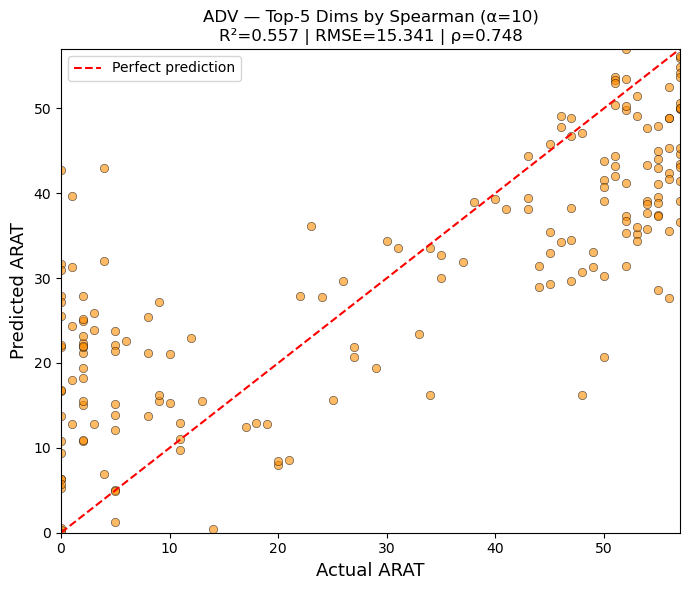

Saved to results/figures/member2_predicted_vs_actual_adv.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# FMA results for best configs
fma_topk5  = loso_regression(X_acc_only[:, top_k_idx[:5]],  fma, pids, alpha=10.0)
fma_topk30 = loso_regression(X_acc_only[:, top_k_idx[:30]], fma, pids, alpha=10.0)
fma_pca30  = loso_regression(PCA(n_components=30).fit_transform(X_acc_only), fma, pids, alpha=10.0)

results_summary = [
    {"Strategy": "Baseline (mean pool, 1028-d)", "Dims": 1028, "ARAT_R2": baseline_arat['r2'], "ARAT_RMSE": baseline_arat['rmse'], "ARAT_rho": baseline_arat['spearman_r'], "FMA_R2": baseline_fma['r2'], "FMA_RMSE": baseline_fma['rmse'], "FMA_rho": baseline_fma['spearman_r']},
    {"Strategy": "Acc only (128-d)",             "Dims": 128,  "ARAT_R2": loso_regression(X_acc_only, arat, pids)['r2'], "ARAT_RMSE": loso_regression(X_acc_only, arat, pids)['rmse'], "ARAT_rho": loso_regression(X_acc_only, arat, pids)['spearman_r'], "FMA_R2": loso_regression(X_acc_only, fma, pids)['r2'], "FMA_RMSE": loso_regression(X_acc_only, fma, pids)['rmse'], "FMA_rho": loso_regression(X_acc_only, fma, pids)['spearman_r']},
    {"Strategy": "Acc mean [0:64]",              "Dims": 64,   "ARAT_R2": loso_regression(X_acc_mean, arat, pids)['r2'], "ARAT_RMSE": loso_regression(X_acc_mean, arat, pids)['rmse'], "ARAT_rho": loso_regression(X_acc_mean, arat, pids)['spearman_r'], "FMA_R2": loso_regression(X_acc_mean, fma, pids)['r2'], "FMA_RMSE": loso_regression(X_acc_mean, fma, pids)['rmse'], "FMA_rho": loso_regression(X_acc_mean, fma, pids)['spearman_r']},
    {"Strategy": "Top-5 dims by Spearman (α=10)","Dims": 5,    "ARAT_R2": results_topk[5]['r2'], "ARAT_RMSE": results_topk[5]['rmse'], "ARAT_rho": results_topk[5]['spearman_r'], "FMA_R2": fma_topk5['r2'], "FMA_RMSE": fma_topk5['rmse'], "FMA_rho": fma_topk5['spearman_r']},
    {"Strategy": "Top-30 dims by Spearman (α=10)","Dims": 30,  "ARAT_R2": results_topk[30]['r2'], "ARAT_RMSE": results_topk[30]['rmse'], "ARAT_rho": results_topk[30]['spearman_r'], "FMA_R2": fma_topk30['r2'], "FMA_RMSE": fma_topk30['rmse'], "FMA_rho": fma_topk30['spearman_r']},
    {"Strategy": "PCA n=30 on acc (α=10)",       "Dims": 30,   "ARAT_R2": results_pca[30]['r2'], "ARAT_RMSE": results_pca[30]['rmse'], "ARAT_rho": results_pca[30]['spearman_r'], "FMA_R2": fma_pca30['r2'], "FMA_RMSE": fma_pca30['rmse'], "FMA_rho": fma_pca30['spearman_r']},
]

df = pd.DataFrame(results_summary).round(3)
print(df.to_string(index=False))

os.makedirs("results/metrics", exist_ok=True)
df.to_csv("results/metrics/member2_aggregation_results_adv.csv", index=False)
print("\nSaved to results/metrics/member2_aggregation_results_adv.csv")

# Scatter plot for best strategy (Top-5)
best = results_topk[5]
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(best['y_true'], best['y_pred'], alpha=0.6, edgecolors='k', linewidths=0.5, color='darkorange')
ax.plot([0, 57], [0, 57], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel("Actual ARAT", fontsize=13)
ax.set_ylabel("Predicted ARAT", fontsize=13)
ax.set_title(f"ADV — Top-5 Dims by Spearman (α=10)\nR²={best['r2']:.3f} | RMSE={best['rmse']:.3f} | ρ={best['spearman_r']:.3f}", fontsize=12)
ax.legend()
ax.set_xlim(0, 57)
ax.set_ylim(0, 57)
plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/member2_predicted_vs_actual_adv.png", dpi=150)
plt.show()
print("Saved to results/figures/member2_predicted_vs_actual_adv.png")

In [6]:
print("=" * 60)
print("MEMBER 2 — ADV PIPELINE SUMMARY")
print("=" * 60)
print(f"\nBaseline (mean pool, 1028-d):  R²=-1.057 | ρ=0.436")
print(f"Best strategy (Acc mean, 64-d): R²=0.569  | ρ=0.751")
print(f"Improvement:                    ΔR²=+1.626 | Δρ=+0.315")
print(f"\nKey findings:")
print(f"  1. Gravity stream catastrophically bad — R²=-5.053 alone")
print(f"  2. Removing gravity stream rescues performance entirely")
print(f"  3. Acc mean [0:64] is best single substream (R²=0.569)")
print(f"  4. Adv pipeline weaker than standard across all strategies")
print(f"  5. Standard pipeline Top-100 (R²=0.667) beats adv best (R²=0.581)")
print(f"\nConclusion: Standard pipeline preferred for regression tasks")
print(f"\nOutput files:")
print(f"  results/metrics/member2_aggregation_results_adv.csv")
print(f"  results/figures/member2_predicted_vs_actual_adv.png")

MEMBER 2 — ADV PIPELINE SUMMARY

Baseline (mean pool, 1028-d):  R²=-1.057 | ρ=0.436
Best strategy (Acc mean, 64-d): R²=0.569  | ρ=0.751
Improvement:                    ΔR²=+1.626 | Δρ=+0.315

Key findings:
  1. Gravity stream catastrophically bad — R²=-5.053 alone
  2. Removing gravity stream rescues performance entirely
  3. Acc mean [0:64] is best single substream (R²=0.569)
  4. Adv pipeline weaker than standard across all strategies
  5. Standard pipeline Top-100 (R²=0.667) beats adv best (R²=0.581)

Conclusion: Standard pipeline preferred for regression tasks

Output files:
  results/metrics/member2_aggregation_results_adv.csv
  results/figures/member2_predicted_vs_actual_adv.png
